In [16]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import random
import time

In [17]:
def set_seeds():
    SEED_VALUE=42
    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

In [18]:
device = torch.device("mps")

In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

#Convert to Tensors and Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean, std
])

# Download and load the training data
train_set = datasets.FashionMNIST(root = "F_MNIST_data", download = True, train = True, transform = transform)
val_set = datasets.FashionMNIST(root = "F_MNIST_data", download = True, train = False, transform = transform) #Test set

print("Total Train Images: ", len(train_set))
print("Total Val Images: ", len(val_set))



Total Train Images:  60000
Total Val Images:  10000


In [20]:
train_loader = torch.utils.data.DataLoader(train_set, shuffle = True, batch_size = 64)
val_loader = torch.utils.data.DataLoader(val_set, shuffle = False, batch_size = 64)


In [21]:
class_mapping= {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"  }

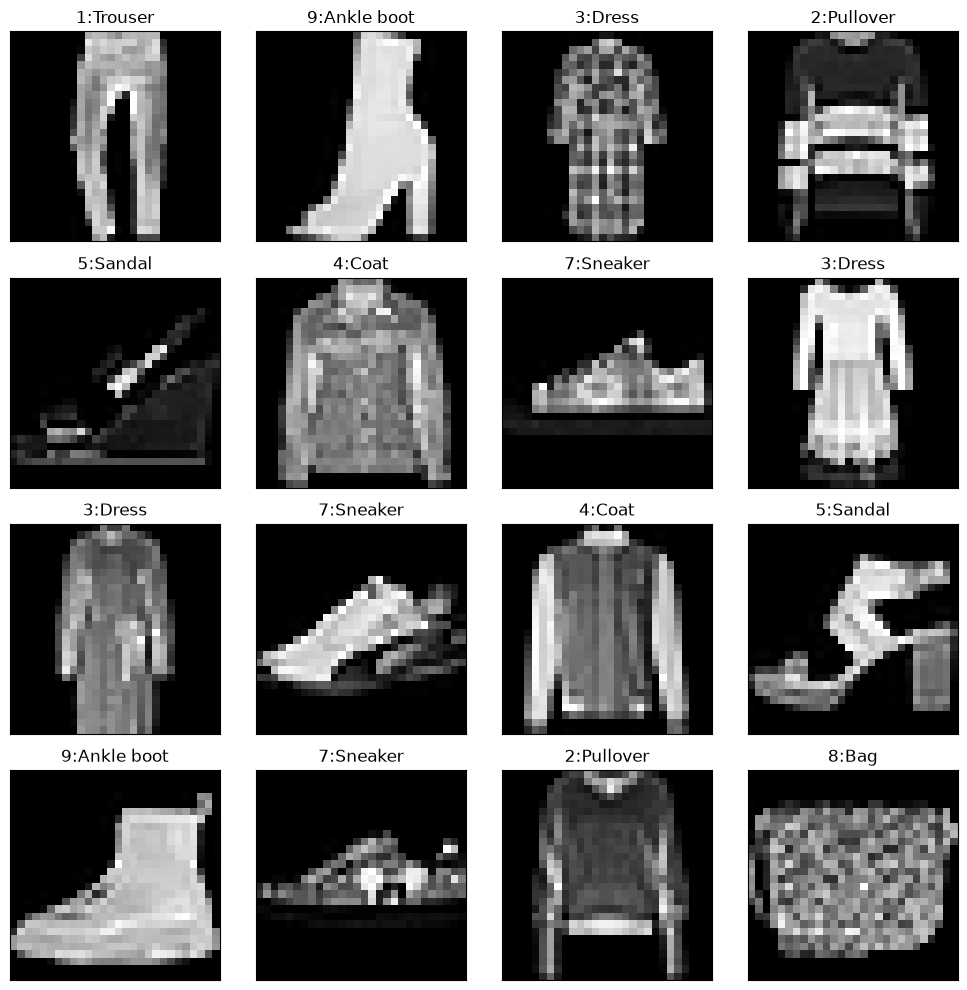

In [22]:
def visualize_images(trainloader, num_images=20):
    fig = plt.figure(figsize=(10,10))

    images, labels = next(iter(trainloader))
    num_rows = 4
    num_cols = int(np.ceil(num_images / num_rows))

    for idx in range(min(num_images, len(images))):
        image, label = images[idx], labels[idx]

        ax = fig.add_subplot(num_rows, num_cols, idx+1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(image), cmap="gray")
        ax.set_title(f"{label.item()}:{class_mapping[label.item()]}")
    fig.tight_layout()
    plt.show()

visualize_images(train_loader,num_images=16)


In [23]:
class MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.fc0 = nn.Linear(784,512) # 28 * 28
        self.bn0 = nn.BatchNorm1d(512)
        self.fc1 = nn.Linear(512,256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256,128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128,64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64,num_classes)

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.bn0(self.fc0(x)))
        x = self.dropout(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.log_softmax(self.fc4(x),dim = 1)

        return x

mlp_model = MLP(num_classes=10)

In [24]:
print(summary(mlp_model, input_size = (1,1,28,28)))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─BatchNorm1d: 1-2                       [1, 512]                  1,024
├─Dropout: 1-3                           [1, 512]                  --
├─Linear: 1-4                            [1, 256]                  131,328
├─BatchNorm1d: 1-5                       [1, 256]                  512
├─Linear: 1-6                            [1, 128]                  32,896
├─BatchNorm1d: 1-7                       [1, 128]                  256
├─Dropout: 1-8                           [1, 128]                  --
├─Linear: 1-9                            [1, 64]                   8,256
├─BatchNorm1d: 1-10                      [1, 64]                   128
├─Linear: 1-11                           [1, 10]                   650
Total params: 576,970
Trainable params: 576,970
Non-trainable

In [25]:
criterion = F.nll_loss
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-2)
num_epochs=40
DEVICE="mps"

In [26]:
def train(model, trainloader, criterion, optimizer, DEVICE):
    model.train()
    model.to(DEVICE)
    running_loss = 0
    correct_precisions=0
    total_samples = 0

    for images, labels in trainloader:
        images, labels = images.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        outputs=model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_samples += labels.size(0)
        correct_precisions += (predicted ==labels).sum().item()

    avg_loss = running_loss / len(trainloader)
    accuracy = 100 * correct_precisions / total_samples
    return avg_loss, accuracy

In [27]:
def validation(model,val_loader, criterion, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_precisions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_precisions += (predicted == labels).sum().item()

    avg_loss = running_loss / len(val_loader)
    accuracy = 100 * correct_precisions / total_samples
    return avg_loss, accuracy

In [28]:
def main(model, trainloader, val_loader, epochs=5, DEVICE="mps"):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = train(model, trainloader, criterion, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, criterion, DEVICE)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1:0>2}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    # Plotting loss and accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

Epoch 01/40 - Train Loss: 0.5617, Train Accuracy: 80.08% - Val Loss: 0.4231, Val Accuracy: 84.48%
Epoch 02/40 - Train Loss: 0.4335, Train Accuracy: 84.47% - Val Loss: 0.4013, Val Accuracy: 85.49%
Epoch 03/40 - Train Loss: 0.4000, Train Accuracy: 85.73% - Val Loss: 0.3595, Val Accuracy: 87.07%
Epoch 04/40 - Train Loss: 0.3756, Train Accuracy: 86.55% - Val Loss: 0.3430, Val Accuracy: 87.60%
Epoch 05/40 - Train Loss: 0.3490, Train Accuracy: 87.34% - Val Loss: 0.3378, Val Accuracy: 88.05%
Epoch 06/40 - Train Loss: 0.3365, Train Accuracy: 87.71% - Val Loss: 0.3357, Val Accuracy: 87.64%
Epoch 07/40 - Train Loss: 0.3258, Train Accuracy: 88.11% - Val Loss: 0.3357, Val Accuracy: 87.56%
Epoch 08/40 - Train Loss: 0.3152, Train Accuracy: 88.44% - Val Loss: 0.3173, Val Accuracy: 88.36%
Epoch 09/40 - Train Loss: 0.3002, Train Accuracy: 89.03% - Val Loss: 0.3090, Val Accuracy: 88.87%
Epoch 10/40 - Train Loss: 0.2915, Train Accuracy: 89.29% - Val Loss: 0.3068, Val Accuracy: 88.42%
Epoch 11/40 - Train 

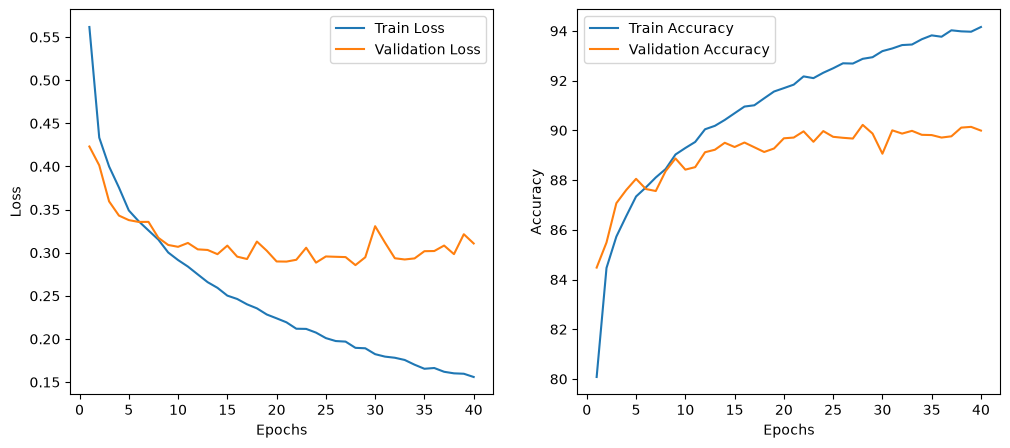

In [29]:
main(mlp_model, train_loader, val_loader, epochs = num_epochs, DEVICE = DEVICE)